# Single-cell Analysis of T-cell Subtypes and Functional Characteristics (Figure 3)

**Manuscript Context:** This notebook contains the code and workflows used to generate **Figure 3a–h** for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to comprehensively characterize the heterogeneity, clonal dynamics, and functional states of T cells within the ENKTCL tumor microenvironment. Specifically, we:
1.  Delineate the landscape of T-cell subpopulations, distinguishing between CD8⁺, CD4⁺, NKT-like, and malignant T-cell clusters.
2.  Integrate Copy Number Variation (CNV) inference with T-cell receptor (TCR) clonality analysis to identify malignant T cells and assess their expansion potential.
3.  Reconstruct the developmental trajectories of CD8⁺ and CD4⁺ T cells to map the transcriptional progression from naïve/memory states to exhausted or terminally differentiated phenotypes.

In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import muon as mu
import pandas as pd
import scanpy as sc
import scirpy as ir
import numpy as np
import os
import seaborn as sns
from scipy.sparse import csc_matrix, csr_matrix
from collections import Counter
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter, PercentFormatter
import sys
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [ ]:
figPath = "./figures/fig3"
irPath = "./data/NKTCL-ir.h5ad"
TPath = './data/NKTCL_T.h5ad'
CD8TPath = './data/NKTCL_CD8T.h5ad'
CD4TPath = './data/NKTCL_CD4T.h5ad'
datPath = "./data/NKTCL_concat.h5ad"

In [ ]:
adata_T = sc.read_h5ad(TPath)
adata_CD4T = sc.read_h5ad(CD4TPath)
adata_CD8T = sc.read_h5ad(CD8TPath)
nktcl_ir = sc.read_h5ad(irPath)

#### **Fig. 3a** UMAP visualization of CD8+, CD4+, proliferation, malignant, and NKT-like T-cell clusters.

In [ ]:
# ---------------------------------------------------------
# Annotate cell clusters based on a mapping dictionary
# ---------------------------------------------------------
# This function assigns biological labels (e.g., cell types) 
# to cells in an AnnData object. It maps specific cluster IDs 
# (from a leiden clustering column) to user-defined annotations 
# based on a provided dictionary, overwriting any existing 
# annotations in the specified observation key.
# ---------------------------------------------------------

def anno(adata:ad.AnnData, annoDict:dict, obsKey='cnv_status', obsVal='cnv_leiden', default="Unknown"):
  if default is not None:
    adata.obs[obsKey] = default
  for key in annoDict.keys():
    adata.obs.loc[adata.obs[obsVal].isin(annoDict[key]), obsKey] = key
  return adata

In [ ]:
# integrate gene expression and TCR data
mdata_CD8T = mu.MuData({'gex': adata_CD8T, "airr":nktcl_ir})
mdata_CD4T = mu.MuData({'gex': adata_CD4T, "airr":nktcl_ir})

In [775]:
# ---------------------------------------------------------
# TCR clonotype definition and expansion analysis
# ---------------------------------------------------------
# This section analyzes the T-cell receptor (TCR) repertoire 
# to identify clonally expanded CD8+ T cells. It calculates 
# sequence distances based on nucleotide identity, defines 
# unique clonotypes by grouping cells with identical receptors, 
# and categorizes the degree of clonal expansion based on the 
# frequency of cells within each clone.
# ---------------------------------------------------------
ir.pp.ir_dist(mdata_CD8T, metric="identity", sequence="nt", key_added="ir_dist_nt_identity", n_jobs=8)
ir.tl.define_clonotypes(mdata_CD8T, key_added="clone_id", same_v_gene=False, dual_ir='primary_only',receptor_arms="all" )
ir.tl.clonal_expansion(mdata_CD8T, target_col="clone_id", key_added="clonal_expansion", breakpoints=[2,5,10,20,40])
ir.pp.ir_dist(mdata_CD4T, metric="identity", sequence="nt", key_added="ir_dist_nt_identity", n_jobs=8)
ir.tl.define_clonotypes(mdata_CD4T, key_added="clone_id", same_v_gene=False, dual_ir='primary_only',receptor_arms="all" )
ir.tl.clonal_expansion(mdata_CD4T, target_col="clone_id", key_added="clonal_expansion", breakpoints=[2,5,10,20,40])

In [ ]:
mdata_CD8T.obs['gex:clonal_size'] = mdata_CD8T.obs['airr:clonal_expansion']
adata_CD8T.obs['clonal_size'] = mdata_CD8T.obs['airr:clonal_expansion']
annot = {
  40: ['<= 40','> 40'],
  20: ['<= 20'],
  10: ['<= 10'],
  5: ['<= 5'],
  3: ['<= 2'],
}
adata_CD8T = anno(adata_CD8T, annot, 'spot_size', 'clonal_size', 2)

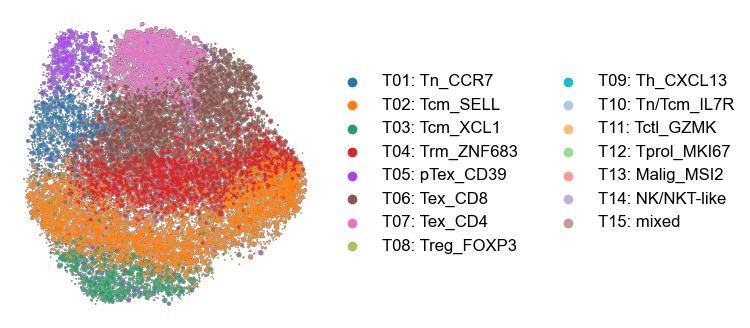

In [772]:
adata_CD8T.obs['CellStateLabels'] = adata_T.obs['CellStateLabels']
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.umap(adata_CD8T,color=['CellStateLabels'], 
           size=adata_CD8T.obs['spot_size'], 
           alpha=0.8, add_outline=True, 
           outline_color=('#5c5a5a','lightgrey'),
           outline_width=(0.15,0.02),
           title='', ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f'{figPath}/Fig3a-CD8T.png', dpi=400, bbox_inches='tight')

In [776]:
mdata_CD4T.obs['gex:clonal_size'] = mdata_CD4T.obs['airr:clonal_expansion']
adata_CD4T.obs['clonal_size'] = mdata_CD4T.obs['airr:clonal_expansion']
annot = {
  40: ['<= 40','> 40'],
  20: ['<= 20'],
  10: ['<= 10'],
  5: ['<= 5'],
  3: ['<= 2'],
}
adata_CD4T = anno(adata_CD4T, annot, 'spot_size', 'clonal_size', 2)

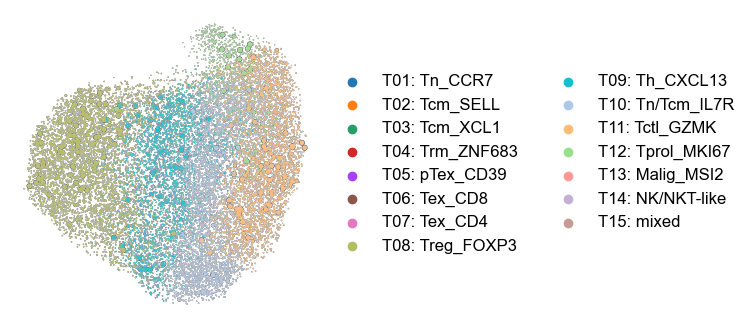

In [777]:
adata_CD4T.obs['CellStateLabels'] = adata_T.obs['CellStateLabels']
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.umap(adata_CD4T,color=['CellStateLabels'], 
           size=adata_CD4T.obs['spot_size'], 
           alpha=0.8, add_outline=True, 
           outline_color=('#5c5a5a','lightgrey'),
           outline_width=(0.15,0.02),
           title='', ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f'{figPath}/Fig3a-CD4T.png', dpi=400, bbox_inches='tight')

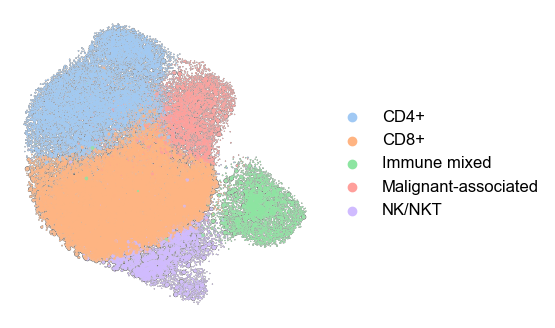

In [778]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.umap(adata_T,color=['anno-T'], 
           size=adata_T.obs['spot_size'], 
           alpha=0.8, add_outline=True, 
           outline_color=('#5c5a5a','lightgrey'),
           outline_width=(0.15,0.02),
           title='', ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f'{figPath}/Fig3a-T.png', dpi=400, bbox_inches='tight')

#### **Fig. 3b** CNV status and proliferation of T cells. 
UMAP plots illustrating CNV-inferred malignancy and proliferation scores across T cells. Malignant T cells are marked in red, and normal cells are marked in gray. The proliferation scores range from low (purple) to high (yellow).

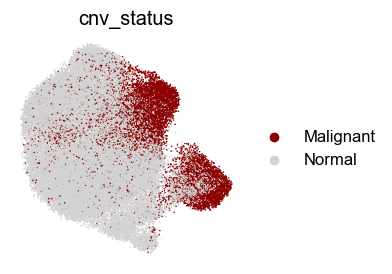

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
palette = sns.color_palette("pastel", 5)
sc.pl.umap(adata_T, color=['cnv_status'],palette=['darkred', 'lightgray'], size=5, ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f'{figPath}/Fig3b-c-cnv_status.png', dpi=150, bbox_inches='tight')

#### **Fig. 3c** Developmental potential of T cells. 
UMAP visualization of T-cell developmental potency inferred by CytoTRACE2, with blue indicating low potential and green indicating high potential. High-potential regions were associated with elevated expression of the stemness-related gene MSI2.

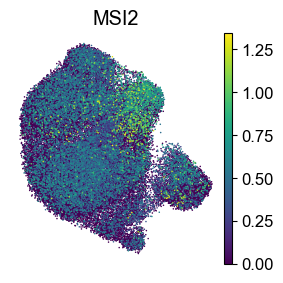

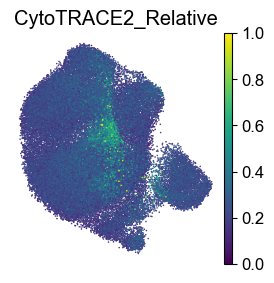

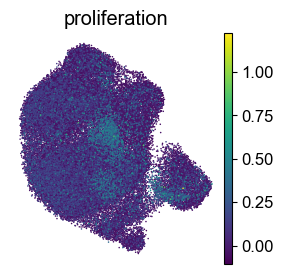

In [780]:
for gene in ['MSI2', 'CytoTRACE2_Relative', 'proliferation']:
  fig, ax = plt.subplots(1, 1, figsize=(3, 3))
  palette = sns.color_palette("pastel", 5)
  sc.pl.umap(adata_T, color=[gene],palette=['darkred', 'lightgray'], size=5, ax=ax, show=False)
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)
  ax.spines['left'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.set_xlabel("")
  ax.set_ylabel("")
  fig.savefig(f'{figPath}/Fig3b-c-{gene}.png', dpi=150, bbox_inches='tight')

#### **Fig. 3d** CNV status and clonal expansion across T-cell subclusters. 
The numbers above the stacked bar represent the proportion of clonally expanded cells among all T cells with TCRs.

In [767]:
# ---------------------------------------------------------
# Generate stacked bar plots for cell proportion analysis
# ---------------------------------------------------------
# This function visualizes the relative abundance of different 
# cell types or states across samples (e.g., patients). It 
# normalizes the input count data to percentages and generates 
# a horizontal stacked bar chart, allowing for easy comparison 
# of compositional differences between groups.
# ---------------------------------------------------------
def propPlot(age_df, barlabels, ax, colors=sc.pl.palettes.default_20, xlabel='Patient ID', show_y=True, xrotate=90):
    all_df = age_df.sum(axis=1)
    age_normdf = pd.DataFrame([age_df.loc[i,:]/all_df[i] for i in barlabels], index=barlabels)
    age_cumdf = pd.DataFrame([np.cumsum(age_normdf.loc[i,:]) for i in barlabels], index=barlabels)
    norm_gdfs = age_normdf
    cum_gdfs = age_cumdf
    for i, col in enumerate(age_df.columns):
        height = norm_gdfs[col]
        starts = cum_gdfs[col] - height
        rects = ax.barh(barlabels, height, left=starts, height=0.9, color=colors[i], edgecolor='white', linewidth=0.5,
                        label=col, alpha=1)
    
        # ax.bar_label(rects,age_df.loc[:, col], label_type='center', color='lightgrey', fontsize=14)
    ax.legend( bbox_to_anchor=(1, 0), 
              handletextpad=0.5, frameon=False,
                          borderpad=0.4,
                          columnspacing=1,
                          handlelength=0.65,
              loc='lower left')
    if show_y:
        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1,decimals=0))
        ax.set_xlabel('Cell proportions')
    else:
        ax.yaxis.set_visible(False)
    ax.set_ylabel(xlabel)
    # ax.set_yticks(barlabels)
    # ax.set_xticklabels(labels=barlabels,rotation=xrotate)
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

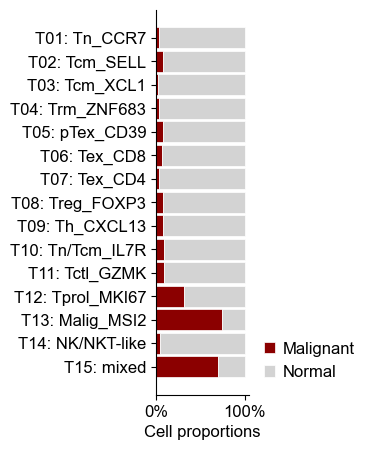

In [768]:
barlabels = list(adata_T.obs['CellStateLabels'].cat.categories)
barlabels.reverse()
cell_types = list(adata_T.obs['cnv_status'].unique())
cell_types.sort()
colors=['darkred', 'lightgrey']
age_df = pd.DataFrame(columns = list(cell_types))
for bar in barlabels:
    d1 = pd.DataFrame([len(adata_T[(adata_T.obs['cnv_status'] == ct) & (adata_T.obs["CellStateLabels"] == bar)]) for ct in list(cell_types)], index = list(cell_types), columns=[bar]).T
    age_df = pd.concat([age_df, d1])
fig0, ax0 = plt.subplots(figsize=(1.2, 5))
propPlot(age_df, ax=ax0, barlabels=barlabels, colors=colors, show_y=True, xlabel="")
fig0.savefig(f"{figPath}/Fig3d-CNV.svg",bbox_inches='tight')

In [782]:
# ---------------------------------------------------------
# Quantify and summarize TCR clonal expansion statistics
# ---------------------------------------------------------
# This function aggregates TCR clonality data across different 
# CD8+ T-cell subclusters. It identifies expanded clones, 
# specifically highlighting the top N most expanded clones, and 
# calculates the total number of cells with productive TCRs. 
# The function returns a summary DataFrame suitable for plotting 
# stacked bar charts, categorizing cells into top expanded clones, 
# other expanded clones, and cells without detected TCRs.
# ---------------------------------------------------------
def get_expand_clonotypes(mdata_CD8T, groupby='gex:anno-CD8T', ntop=5):
  batches = mdata_CD8T.obs[groupby].cat.categories
  cloneCounts = {}
  for ct in list(batches):
    _mdata = mdata_CD8T[mdata_CD8T.obs[groupby] == ct]
    expanded_clonotypes = _mdata.obs[_mdata.obs["airr:clone_id_size"] > 1]["airr:clone_id"]
    clonotype_counts = pd.Series(expanded_clonotypes.value_counts())
    cloneCounts[ct] = clonotype_counts
  mdata_CD8T.obs['airr:cells_with_TCRs'] = mdata_CD8T.obs['airr:clone_id_size'] > 0
  bcr = mdata_CD8T.obs[[groupby,'airr:cells_with_TCRs']]
  bcr['cells_with_TCRs'] = ['with' if x == True else 'without' for x in bcr['airr:cells_with_TCRs']]
  bcr = bcr.dropna()
  bcr_df = ir.tl.summarize_clonal_expansion(mdata_CD8T, groupby=groupby, normalize=False, summarize_by='cell')
  bcr_df['clonally_expanded'] = bcr_df['<= 2'] + bcr_df['> 2']
  bcr_df['T cells with TCR'] = bcr_df['<= 1']
  bcr_df[f'Top expanded'] = [cloneCounts[x].nlargest(ntop).sum() for x in bcr_df.index]
  barlabels = mdata_CD8T.obs[groupby].cat.categories
  cell_types = list(bcr['cells_with_TCRs'].unique())
  cell_types.sort()
  age_df = pd.DataFrame(columns = list(cell_types))
  for bar in barlabels:
      d1 = pd.DataFrame([len(bcr.loc[(bcr['cells_with_TCRs'] == ct) & (bcr[groupby] == bar)]) for ct in list(cell_types)], index = list(cell_types), columns=[bar]).T
      age_df = pd.concat([age_df, d1])
  age_df = pd.concat([age_df, bcr_df[['clonally_expanded', 'T cells with TCR', f'Top expanded']]], axis=1)
  age_df = age_df.fillna(0)
  age_df = age_df[[f'Top expanded', 'clonally_expanded', 'T cells with TCR', 'without']]
  age_df['clonally_expanded'] = age_df['clonally_expanded'] - age_df[f'Top expanded']
  return age_df, cloneCounts

In [784]:
# ---------------------------------------------------------
# Generate customizable stacked bar plots for cell counts or proportions
# ---------------------------------------------------------
# This function creates horizontal stacked bar charts to visualize
# cell abundance across different groups. It supports two modes:
# 'count' for absolute numbers and 'proportion' for relative percentages.
# Additionally, it allows for flexible annotation of the bars, such as
# displaying total cell counts, expansion rates, or top clone rates,
# making it suitable for summarizing clonal expansion and TCR status.
# ---------------------------------------------------------
def countPlot(age_df, barlabels, ax, 
            colors=sc.pl.palettes.default_20, 
            xlabel='Patient ID',  
            mode='count',  
            show_label=True, bar_label='total', show_y=True):
    all_df = age_df.sum(axis=1)
    if mode == 'count':
        age_normdf = pd.DataFrame([age_df.loc[i,:] for i in barlabels], index=barlabels)
    else:
        age_normdf = pd.DataFrame([age_df.loc[i,:] / all_df[i] for i in barlabels], index=barlabels)
    age_cumdf = pd.DataFrame([np.cumsum(age_normdf.loc[i,:]) for i in barlabels], index=barlabels)
    norm_gdfs = age_normdf
    cum_gdfs = age_cumdf
    for i, col in enumerate(age_df.columns):
        height = norm_gdfs[col]
        starts = cum_gdfs[col] - height
        rects = ax.barh(barlabels, height, left=starts, height=0.9, color=colors[i], edgecolor='white', linewidth=0.5,
                        label=col, alpha=1)
    if bar_label == 'total':
        counts = [int(val) for val in all_df]
    elif bar_label == 'topRate':
        counts = (age_df.iloc[:, 0] / (age_df.iloc[:, 0] + age_df.iloc[:, 1])).fillna(0)
        counts = counts[barlabels]
        counts = [round(val, 2) for val in counts]
    elif bar_label == 'expRate':
        counts = ((age_df.iloc[:, 0] + age_df.iloc[:, 1]) / (age_df.iloc[:, 0] + age_df.iloc[:, 1] + age_df.iloc[:, 2])).fillna(0)
        counts = counts[barlabels]
        counts = [round(val, 2) for val in counts]
    else:
        counts = [int(val) for val in age_normdf.loc[:, age_normdf.columns[0]]]
    if show_label:
        ax.bar_label(rects, counts, 
                    label_type='edge', color='#7f3730', fontsize=10)
        # ax.bar_label(rects,age_df.loc[:, col], label_type='center', color='lightgrey', fontsize=14)
    ax.legend( bbox_to_anchor=(1.2, 0.3), 
              handletextpad=0.5, frameon=False,
                          borderpad=0.4,
                          columnspacing=1,
                          handlelength=0.65,
              loc='lower left')
    ax.set_ylabel(xlabel)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    if not show_y:
        ax.set_yticks([])
    # def ks(x, pos):
    #     return '%1.1fk' % (x*1e-3)
    # ax.xaxis.set_major_formatter(FuncFormatter(ks))
    # ax.set_yticks(barlabels)
    # ax.set_xticklabels(labels=barlabels,rotation=xrotate)
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

In [ ]:
mdata_T = mu.MuData({'gex': adata_T, "airr":nktcl_ir})
ir.pp.index_chains(mdata_T)
ir.tl.chain_qc(mdata_T)
ir.pp.ir_dist(mdata_T, metric="identity", sequence="nt", key_added="ir_dist_nt_identity", n_jobs=8)
ir.tl.define_clonotypes(mdata_T, key_added="clone_id", same_v_gene=False, dual_ir='primary_only',receptor_arms="all" )
ir.tl.clonal_expansion(mdata_T, target_col="clone_id", key_added="clonal_expansion", breakpoints=[2,5,10,20,40])
mdata_T.obs['gex:clonal_size'] = mdata_T.obs['airr:clonal_expansion']
adata_T.obs['clonal_size'] = mdata_T.obs['airr:clonal_expansion']
annot = {
  30: ['<= 40','> 40'],
  20: ['<= 20'],
  10: ['<= 10'],
  5: ['<= 5'],
  3: ['<= 2'],
}
adata_T = anno(adata_T, annot, 'spot_size', 'clonal_size', 2)

/tmp/ipykernel_3335451/4236326232.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_3335451/4236326232.py:36: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_3335451/1968069214.py:52: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



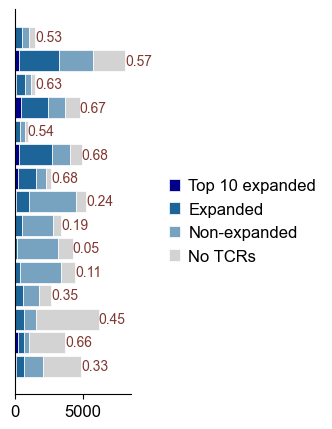

In [785]:
age_df, _ = get_expand_clonotypes(mdata_T, groupby='gex:anno-subTfixed', ntop=10)
age_df = age_df.sort_index(ascending=False)
fig0, ax0 = plt.subplots(figsize=(1.5, 5))
# colors=['darkred','#cc6b61', '#ebc4c0', 'lightgrey']
colors=['darkblue','#1d6598', '#77a3c1', 'lightgrey']
age_df.columns = ['Top 10 expanded','Expanded', 'Non-expanded', 'No TCRs']
barlabels = age_df.index
countPlot(age_df, ax=ax0, barlabels=barlabels, colors=colors, bar_label='expRate', xlabel='', mode='count', show_y=False)
fig0.savefig(f"{figPath}/Fig3d-TCR.svg",bbox_inches='tight')

#### **Fig. 3e** Expression of T-cell markers and various genes. 
Dot plot showing the mean expression of canonical T-cell markers and highly variable genes across T-cell subclusters. Dot size reflects the fraction of expressing cells; color intensity indicates average expression levels. 

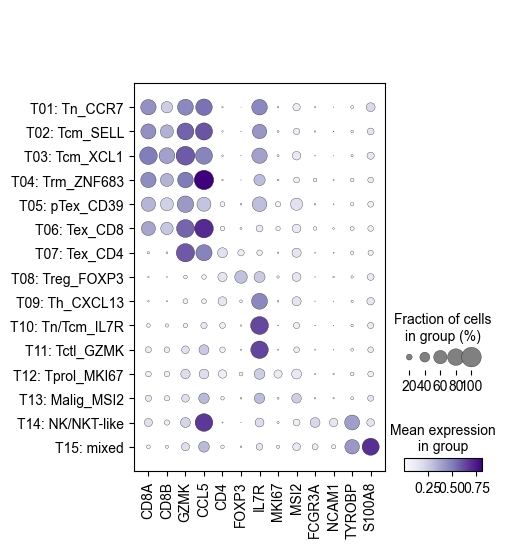

In [764]:
fig, ax = plt.subplots(1,1,figsize=(4.5,6))
sc.pl.dotplot(adata_T, groupby='CellStateLabels',  cmap='Purples', var_names=[
  'CD8A', 'CD8B', 'GZMK', 'CCL5','CD4', "FOXP3",'IL7R','MKI67','MSI2', 'FCGR3A','NCAM1', 'TYROBP','S100A8'], ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
fig.savefig(f"{figPath}/Fig3e.svg", bbox_inches='tight')

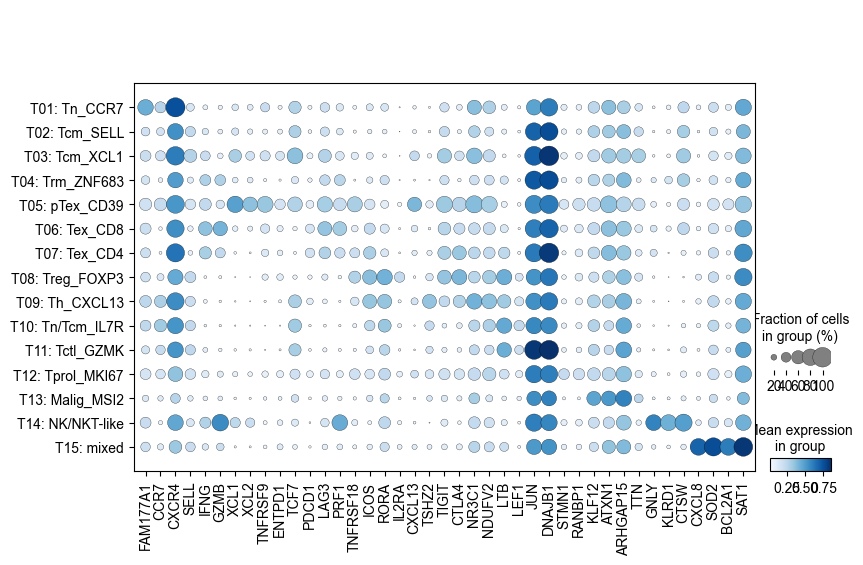

In [765]:
fig, ax = plt.subplots(1,1,figsize=(9,6))
sc.pl.dotplot(adata_T, groupby='CellStateLabels',  cmap='Blues', var_names=[
    'FAM177A1','CCR7', 'CXCR4', 'SELL','IFNG','GZMB', "XCL1", "XCL2",'TNFRSF9','ENTPD1','TCF7', 'PDCD1',"LAG3", 'PRF1',  
    'TNFRSF18', 'ICOS', 'RORA',
  'IL2RA','CXCL13','TSHZ2', 'TIGIT', "CTLA4", 'NR3C1', 'NDUFV2','LTB','LEF1', 'JUN','DNAJB1',"STMN1", 
  'RANBP1','KLF12','ATXN1','ARHGAP15', 'TTN', 'GNLY', 'KLRD1','CTSW','CXCL8', 'SOD2', 'BCL2A1', 'SAT1'], ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
fig.savefig(f"{figPath}/NKTCL-Tvariables.svg", bbox_inches='tight')

#### **Fig. 3f** Gene trajectory of expanded CD8+ T cells. 
Three-dimensional trajectory plot of expanded CD8+ T cells segmented into four transcriptional states: naïve, memory, cytotoxic, and inhibited. 

In [ ]:
# ---------------------------------------------------------
# GeneTrajectory Analysis Workflow
# ---------------------------------------------------------
# This section defines the pipeline for inferring gene trajectories
# using the GeneTrajectory method. Unlike traditional cell trajectory
# inference, this approach analyzes the dynamics of gene expression
# distributions across a cell graph using optimal transport metrics.
# It identifies sequential gene programs and their pseudo-temporal
# ordering without relying on predefined cell lineages.
# ---------------------------------------------------------

from datetime import datetime
from gene_trajectory.add_gene_bin_score import add_gene_bin_score
from gene_trajectory.coarse_grain import select_top_genes, coarse_grain_adata
from gene_trajectory.extract_gene_trajectory import get_gene_embedding, extract_gene_trajectory
from gene_trajectory.get_graph_distance import get_graph_distance
from gene_trajectory.gene_distance_shared import cal_ot_mat
from gene_trajectory.run_dm import run_dm
from gene_trajectory.plot.gene_trajectory_plots import plot_gene_trajectory_3d, plot_gene_trajectory_umap, plot_gene_trajectory_2d
from gene_trajectory.util.download_file import download_file_if_missing

def timeprint(string):
  print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {string}")

def run_gene_trajectory(adata, add_genes=[]):
  timeprint("Start running gene trajectory...")
  genes = select_top_genes(adata, layer='Raw', n_variable_genes=500)
  timeprint(f"Found {len(genes)} highly variable genes.")
  genes = list(genes)
  genes.extend(add_genes)
  genes = np.unique(genes)
  run_dm(adata)
  timeprint("Running Cell graph...")
  cell_graph_dist = get_graph_distance(adata, k=10)
  gene_expression_updated, graph_dist_updated = coarse_grain_adata(adata, graph_dist=cell_graph_dist, features=genes, n=500)
  timeprint("Evaluating gene distance...")
  gene_dist_mat = cal_ot_mat(gene_expr=gene_expression_updated, 
                           ot_cost=graph_dist_updated, 
                           show_progress_bar=True)
  timeprint("Generating gene distance...")
  gene_embedding, _ = get_gene_embedding(gene_dist_mat, k = 5)
  timeprint("Generating gene_trajectory...")
  gene_trajectory = extract_gene_trajectory(gene_embedding, gene_dist_mat, t_list = [4, 8, 7], gene_names=genes, k=5)
  return gene_trajectory

def refine_gene_trajectory(adata, genes):
  timeprint("Running Cell graph...")
  cell_graph_dist = get_graph_distance(adata, k=10)
  gene_expression_updated, graph_dist_updated = coarse_grain_adata(adata, graph_dist=cell_graph_dist, features=genes, n=500)
  timeprint("Evaluating gene distance...")
  gene_dist_mat = cal_ot_mat(gene_expr=gene_expression_updated, 
                           ot_cost=graph_dist_updated, 
                           show_progress_bar=True)
  timeprint("Generating gene distance...")
  gene_embedding, _ = get_gene_embedding(gene_dist_mat, k = 5)
  timeprint("Generating gene_trajectory...")
  gene_trajectory = extract_gene_trajectory(gene_embedding, gene_dist_mat, t_list = [4, 8, 7], gene_names=genes, k=5)
  return gene_trajectory

/home/rzh/miniconda3/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning:

The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.



In [796]:
adata_expand = adata_CD8T[adata_CD8T.obs['spot_size']>=3]
gene_trajectory_expand = run_gene_trajectory(adata_expand, add_genes=['HLA-DQA1', 'SELL','CCR7','PDCD1', 'GZMK', 'ENTPD1', 'TIGIT', 
                                                                      'HAVCR2', 'CD200','TCF7', 'IL7R', 'ZNF683', 'LAG3', 'CTLA4',
                                                                      'ITGAE', 'HAVCR2', 'GZMB'])

[2026-04-10 03:47:35] Start running gene trajectory...


/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/preprocessing/_qc.py:145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



[2026-04-10 03:47:37] Found 382 highly variable genes.
[2026-04-10 03:52:54] Running Cell graph...
[2026-04-10 03:54:06] Evaluating gene distance...


100%|█████████████████████████████████| 77421/77421 [00:05<00:00, 15424.75it/s]


[2026-04-10 03:56:10] Generating gene distance...
[2026-04-10 03:56:10] Generating gene_trajectory...


WARNING	root:extract_gene_trajectory.py:extract_gene_trajectory()- Early stop reached. 0 gene trajectories were retrieved.


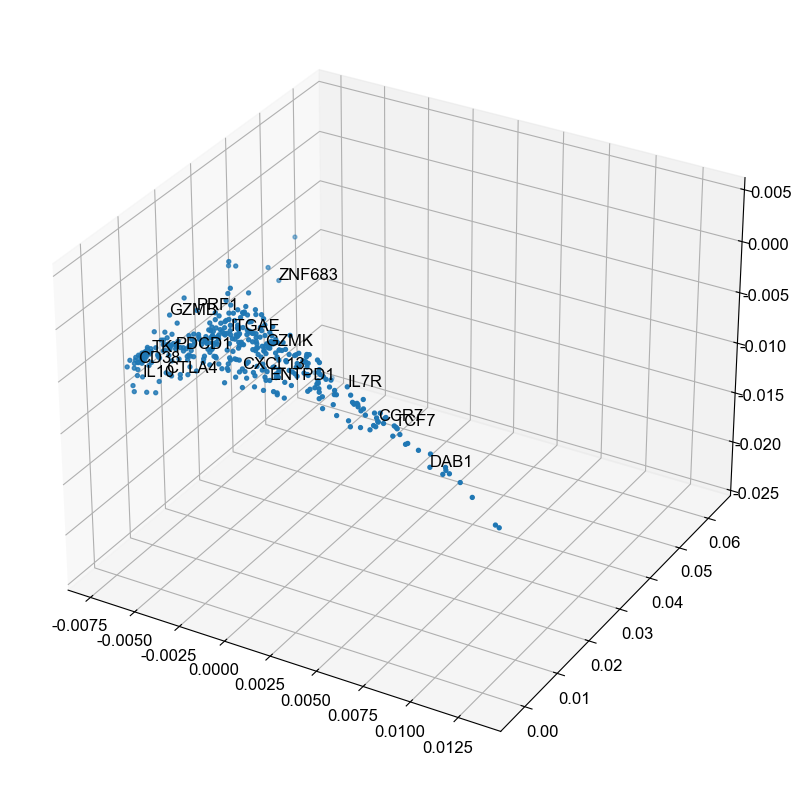

In [797]:
fig = plt.figure(figsize=(10, 10)) 
ax = fig.add_subplot(111, projection='3d')
label_genes=['CD38','IL10','CCR7', 'ITGAE',  'GZMB','TK1','ENTPD1','CTLA4','ZNF683','IL7R','TCF7','PDCD1','DAB1','PRF1', 'GZMK',  'CXCL13',]
gene_trajectory = gene_trajectory_expand
s=8
selections = pd.Categorical(gene_trajectory.selected)

for c in 'DM_1', 'DM_2', 'DM_3', 'selected':
    if c not in gene_trajectory.columns:
        raise ValueError(f'Column {c} is not present in gene trajectory DataFrame')
for c in selections.categories:
    idxs = selections == c
    ax.scatter(xs=gene_trajectory['DM_1'][idxs],
                ys=gene_trajectory['DM_2'][idxs],
                zs=gene_trajectory['DM_3'][idxs],
                s=s,
                label=c)

if label_genes:
    for g in label_genes:
        ax.text(x=gene_trajectory['DM_1'][g],
                y=gene_trajectory['DM_2'][g],
                z=gene_trajectory['DM_3'][g],
                s=g)
fig.savefig(f"{figPath}/Fig3f.pdf", bbox_inches='tight')

#### **Fig. 3g** Expression of key markers across CD8+ T-cell differentiation states. 
UMAP plots showing the distribution of ZNF683, DAB1, GZMB, and CD38 expression across naïve/central memory (Tn/cm), tissue-resident (Trm), progenitor-exhausted (pTex), and terminally exhausted (Tex) T-cell subsets.

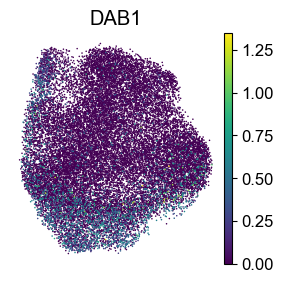

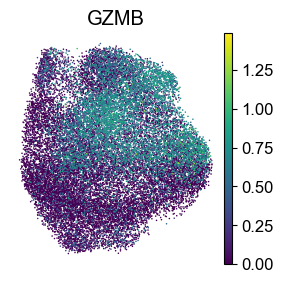

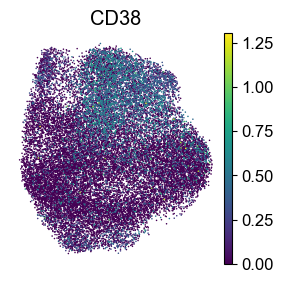

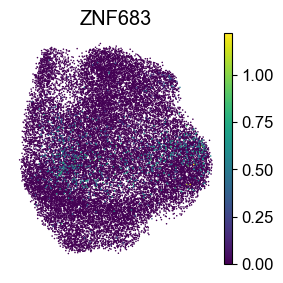

In [794]:
for gene in ['DAB1', 'GZMB', 'CD38', 'ZNF683']:
  fig, ax = plt.subplots(1, 1, figsize=(3, 3))
  palette = sns.color_palette("pastel", 5)
  sc.pl.umap(adata_CD8T, color=[gene],palette=['darkred', 'lightgray'], size=5, ax=ax, show=False)
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)
  ax.spines['left'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.set_xlabel("")
  ax.set_ylabel("")
  fig.savefig(f'{figPath}/Fig3g-{gene}.png', dpi=150, bbox_inches='tight')

#### **Fig. 3h** Gene trajectory of CD4⁺ T cells. 
Scatter plot showing the transcriptional progression of CD4⁺ T cells across different differentiation states. Key genes enriched in the early (e.g., CCR7), intermediate (e.g., GNLY and CCL4L2), and late (e.g., FOXP3, IL17A, CXCR6, and CCR8) stages are labeled.

In [787]:
gene_trajectory_CD4 = run_gene_trajectory(adata_CD4T)

[2026-04-09 18:23:09] Start running gene trajectory...
[2026-04-09 18:23:28] Found 347 highly variable genes.
[2026-04-09 18:28:13] Running Cell graph...
[2026-04-09 18:29:09] Evaluating gene distance...


100%|█████████████████████████████████| 60031/60031 [00:03<00:00, 15872.01it/s]


[2026-04-09 18:30:43] Generating gene distance...
[2026-04-09 18:30:43] Generating gene_trajectory...


WARNING	root:extract_gene_trajectory.py:extract_gene_trajectory()- Early stop reached. 0 gene trajectories were retrieved.


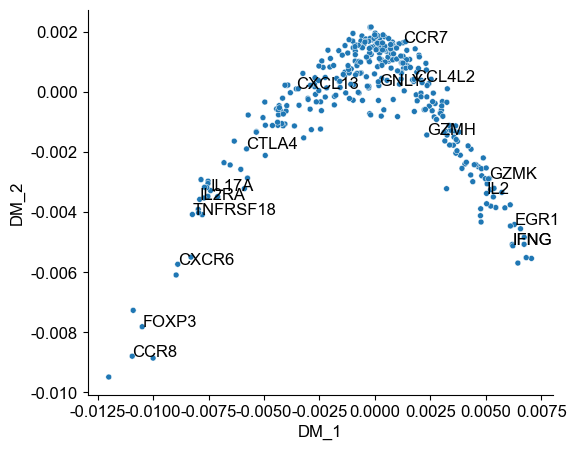

In [788]:
# ---------------------------------------------------------
# Visualize 2D gene trajectory for CD4+ T cells
# ---------------------------------------------------------
# This section generates a 2D projection of the gene trajectory 
# for CD4+ T cells. It selects a subset of cells based on their 
# pseudo-temporal ordering to focus on a specific developmental 
# window. The plot maps the relative positions of key functional 
# genes (e.g., cytokines, transcription factors, and exhaustion 
# markers) to illustrate the transcriptional progression and 
# functional differentiation states of CD4+ T cells.
# ---------------------------------------------------------
gene_trajectory_CD4.sort_values(by='Pseudoorder-1')[50:100]
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plot_gene_trajectory_2d(gene_trajectory_CD4,size=5,label_genes=['CCL4L2','GZMH','IL17A','IFNG','EGR1','IL2','GZMK','CCR7','GNLY','CXCL13','CTLA4','IFNG','IL2RA','TNFRSF18', 'CXCR6',  'FOXP3', 'CCR8'], ax=ax)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend_.set_visible(False)
fig.savefig(f'{figPath}/Fig3i.pdf', bbox_inches='tight')